## import

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


## Data Load

In [28]:
df = pd.read_excel("C:/Users/jwChoi/Desktop/Data/ar-2017-2018.xlsx","Anonymised register")
df.columns

Index(['Patient age at treatment', 'Total number of previous IVF cycles',
       'Total number of previous DI cycles',
       'Total number of previous pregnancies - IVF and DI',
       'Total number of previous live births - IVF or DI',
       'Causes of infertility - tubal disease',
       'Causes of infertility - ovulatory disorder',
       'Causes of infertility - male factor',
       'Causes of infertility - patient unexplained',
       'Causes of infertility - endometriosis',
       'Main reason for producing embroys storing eggs', 'Stimulation used',
       'Egg donor age at registration', 'Sperm donor age at registration',
       'Donated embryo', 'Type of treatment - IVF or DI',
       'Specific treatment type', 'PGT-M treatment', 'PGT-A treatment',
       'Elective single embryo transfer', 'Egg source', 'Sperm source',
       'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)',
       'Fresh eggs collected', 'Fresh eggs stored (0/1)', 'Total eggs mixed',
       'Total embryos 

##### 결측치 시각화

Patient age at treatment                                  0
Total number of previous IVF cycles                       0
Total number of previous DI cycles                        0
Total number of previous pregnancies - IVF and DI    126928
Total number of previous live births - IVF or DI      64529
                                                      ...  
Heart three delivery date                            169536
Patient ethnicity                                         0
Partner ethnicity                                         0
Partner Type                                          10176
Partner age                                           16933
Length: 61, dtype: int64


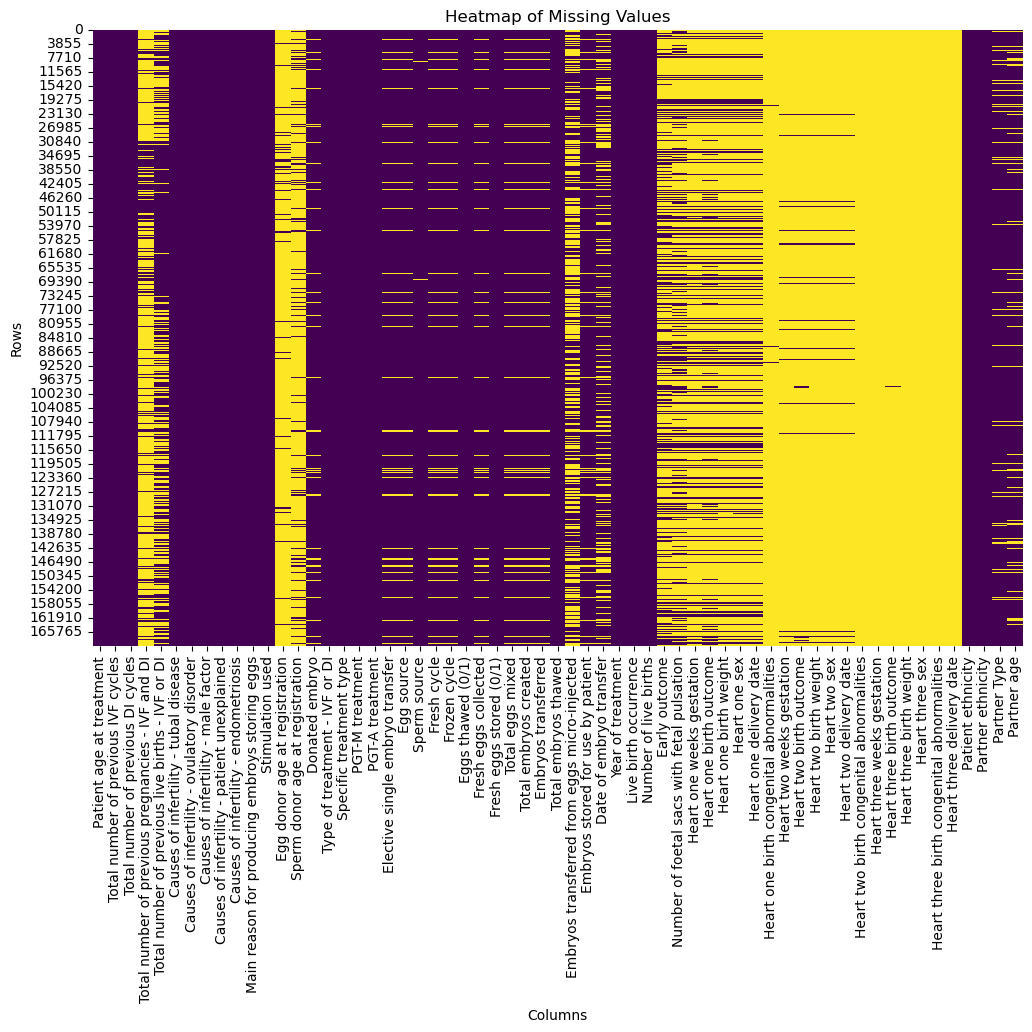

In [29]:
print(df.isnull().sum()) # 결측치 개수 출력

# 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [30]:
# 결측치 비율 계산
missing_ratio = df.isnull().mean()
print(missing_ratio)

# 결측치 비율이 10% 이하인 열만 보존
threshold = 0.1
columns_keep = missing_ratio[missing_ratio <= threshold].index
df_filtered = df[columns_keep]
df_filtered

Patient age at treatment                             0.000000
Total number of previous IVF cycles                  0.000000
Total number of previous DI cycles                   0.000000
Total number of previous pregnancies - IVF and DI    0.748326
Total number of previous live births - IVF or DI     0.380442
                                                       ...   
Heart three delivery date                            0.999528
Patient ethnicity                                    0.000000
Partner ethnicity                                    0.000000
Partner Type                                         0.059994
Partner age                                          0.099831
Length: 61, dtype: float64


,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,Main reason for producing embroys storing eggs,Stimulation used,...,Embryos transferred,Total embryos thawed,Embryos stored for use by patient,Year of treatment,Live birth occurrence,Number of live births,Patient ethnicity,Partner ethnicity,Partner Type,Partner age
0,45-50,3,0,0,0,0,0,0,Embryo storage,0,...,0.0,0,0,2017,0,0,Black,Other,Male,NaN
1,18-34,0,0,0,0,0,0,0,Donation,1,...,0.0,0,0,2018,0,0,White,Other,NaN,NaN
2,999,0,0,0,0,0,0,0,Donation,1,...,0.0,0,0,2018,0,0,Other,Other,NaN,NaN
3,18-34,0,0,0,0,1,0,0,Treatment - IVF,1,...,1.0,0,1-5,2018,0,0,White,White,Male,18-34
4,18-34,1,0,0,0,1,0,0,Treatment - IVF,0,...,1.0,1-5,0,2018,0,0,White,White,Male,18-34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169611,18-34,0,0,1,0,0,0,0,Treatment - IVF,1,...,1.0,0,1-5,2017,0,0,Other,White,Male,18-34
169612,18-34,1,0,1,0,0,0,0,Treatment - IVF,0,...,1.0,1-5,0,2017,0,0,Other,White,Male,18-34
169613,18-34,2,0,1,0,0,0,0,Treatment - IVF,0,...,2.0,1-5,0,2017,1,1,Other,White,Male,18-34
169614,35-37,0,0,0,0,1,0,0,Treatment - IVF,1,...,1.0,0,1-5,2017,1,1,Other,Other,Male,35-37


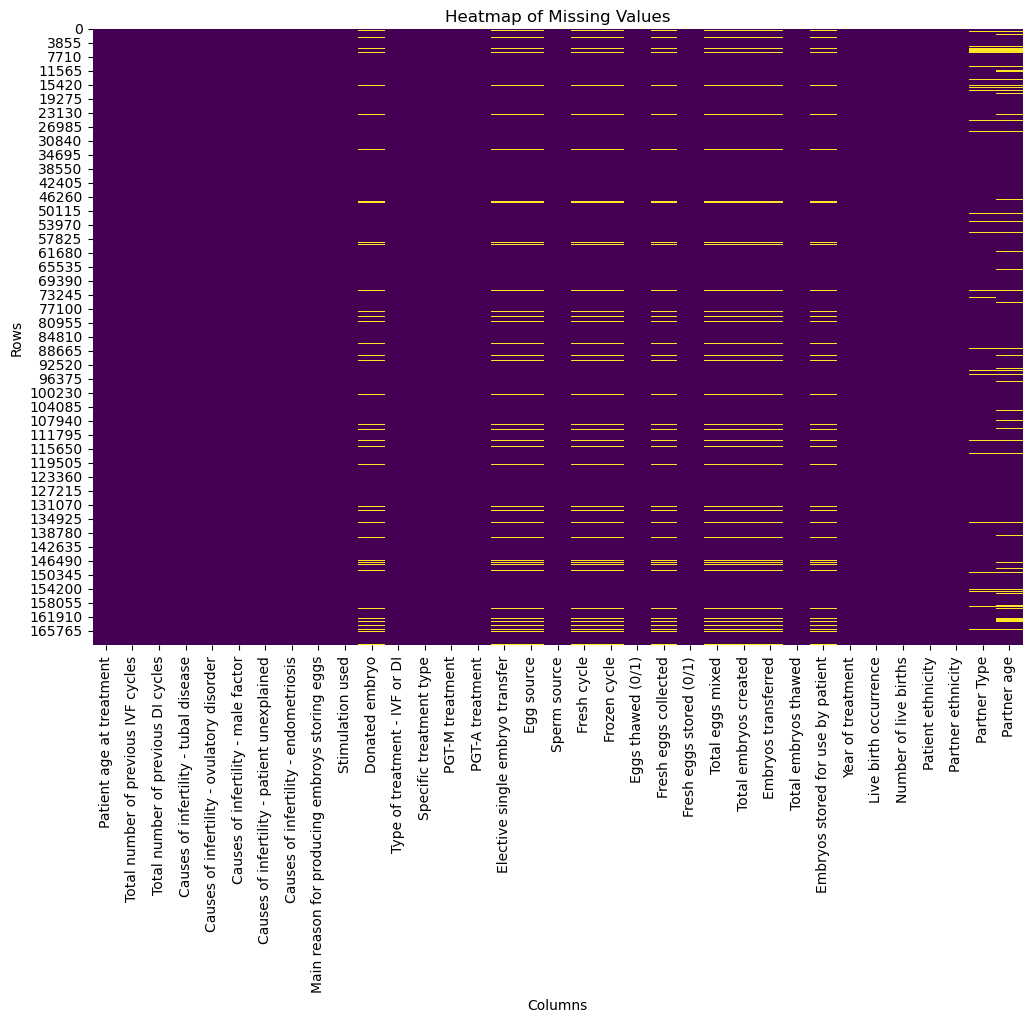

In [31]:
# 결측치 비율 0.1이상인 열 제거한한 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

In [32]:
df_filtered.dtypes

Patient age at treatment                           object
Total number of previous IVF cycles                object
Total number of previous DI cycles                 object
Causes of infertility - tubal disease               int64
Causes of infertility - ovulatory disorder          int64
Causes of infertility - male factor                 int64
Causes of infertility - patient unexplained         int64
Causes of infertility - endometriosis               int64
Main reason for producing embroys storing eggs     object
Stimulation used                                    int64
Donated embryo                                    float64
Type of treatment - IVF or DI                      object
Specific treatment type                            object
PGT-M treatment                                     int64
PGT-A treatment                                     int64
Elective single embryo transfer                   float64
Egg source                                         object
Sperm source  

In [33]:
# 숫자형 열
numerical_columns = df_filtered.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("숫자형 열:", numerical_columns)

# 범주형 열
categorical_columns = df_filtered.select_dtypes(include=['object']).columns.tolist()
print("범주형 열:", categorical_columns)

숫자형 열: ['Causes of infertility - tubal disease', 'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor', 'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis', 'Stimulation used', 'Donated embryo', 'PGT-M treatment', 'PGT-A treatment', 'Elective single embryo transfer', 'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)', 'Fresh eggs stored (0/1)', 'Embryos transferred', 'Year of treatment', 'Live birth occurrence', 'Number of live births']
범주형 열: ['Patient age at treatment', 'Total number of previous IVF cycles', 'Total number of previous DI cycles', 'Main reason for producing embroys storing eggs', 'Type of treatment - IVF or DI', 'Specific treatment type', 'Egg source', 'Sperm source', 'Fresh eggs collected', 'Total eggs mixed', 'Total embryos created', 'Total embryos thawed', 'Embryos stored for use by patient', 'Patient ethnicity', 'Partner ethnicity', 'Partner Type', 'Partner age']


#### 범주형 열의 결측치는 'Unknown'

In [34]:
df_filtered[categorical_columns] = df_filtered[categorical_columns].fillna('Unknown')

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\3821339163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[categorical_columns] = df_filtered[categorical_columns].fillna('Unknown')


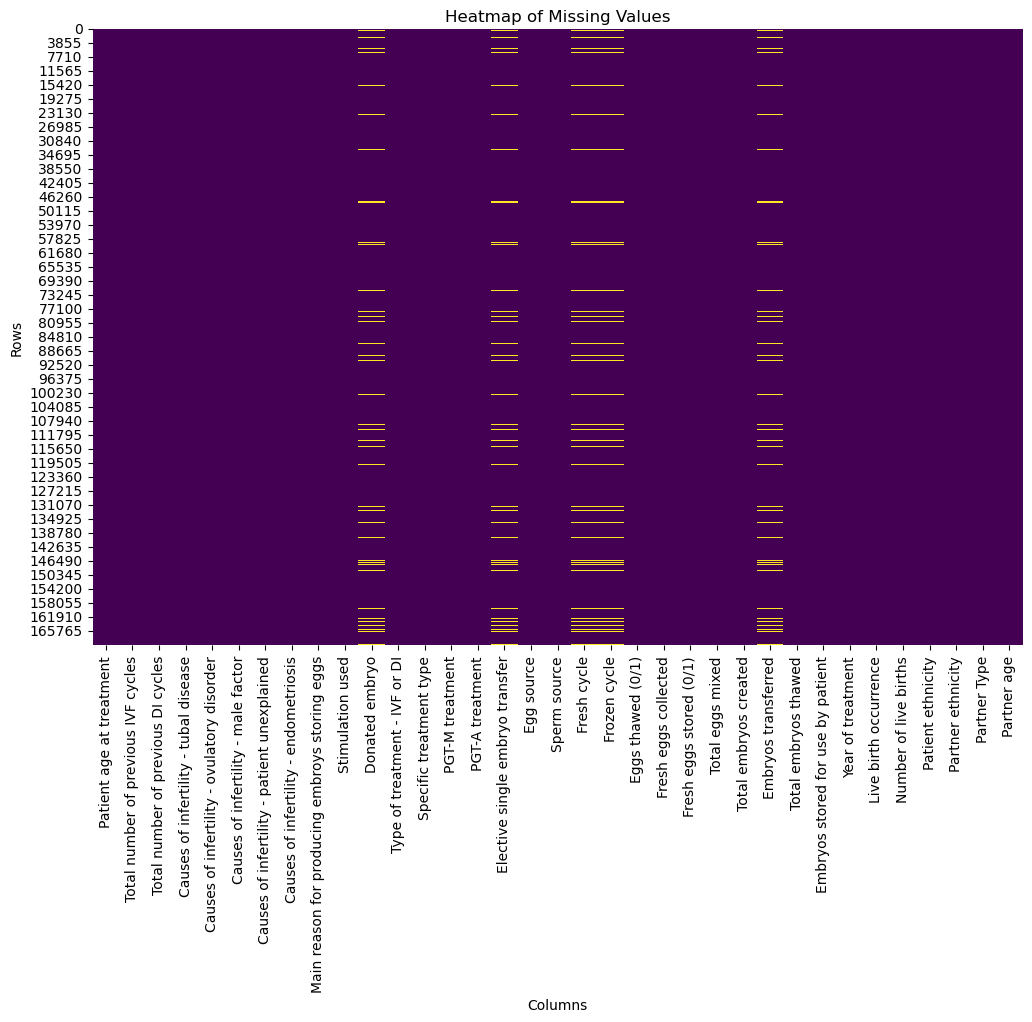

In [35]:
# 범주형 열 채운 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtered.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 이상치 처리

In [36]:
# 나이 999 -> 'Unknown'
df_filtered['Patient age at treatment'] = df_filtered['Patient age at treatment'].replace(999, 'Unknown')
df_filtered['Partner age'] = df_filtered['Partner age'].replace(999, 'Unknown')

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\3027466964.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Patient age at treatment'] = df_filtered['Patient age at treatment'].replace(999, 'Unknown')
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\3027466964.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Partner age'] = df_filtered['Partner age'].replace(999, 'Unknown')


### 숫자형 데이터인데 결측치 있는(Embryos transferred만 number 나머지 bit)

In [37]:
missing_numerical_columns = df_filtered[numerical_columns].isnull().sum()

# 결측치가 있는 열만 선택
missing_cols = missing_numerical_columns[missing_numerical_columns > 0].index

# 해당 열들의 데이터 타입 확인
missing_data_types = df_filtered[missing_cols].dtypes
print(missing_data_types)


Donated embryo                     float64
Elective single embryo transfer    float64
Fresh cycle                        float64
Frozen cycle                       float64
Embryos transferred                float64
dtype: object


##### 따로 처리

In [38]:
median_value = df_filtered["Embryos transferred"].median() # 중앙값
df_filtered["Embryos transferred"].fillna(median_value, inplace=True)


C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\3917487290.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered["Embryos transferred"].fillna(median_value, inplace=True)
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\3917487290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Embryos transferred"].fillna(median_

## 범주형 데이터 레이블 인코딩

In [39]:
# 레이블 인코더 저장을 위한 딕셔너리
encoders = {}

# 열별 레이블 인코딩
for column in categorical_columns:
    # 레이블 인코더 생성
    encoder = LabelEncoder()
    
    # 레이블 인코딩 적용 및 데이터프레임 업데이트
    df_filtered[column] = encoder.fit_transform(df_filtered[column].astype(str))  # 결측값이 있거나 비문자열이면 변환
    
    # 각 열의 인코더 저장
    encoders[column] = encoder

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\1485519449.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[column] = encoder.fit_transform(df_filtered[column].astype(str))  # 결측값이 있거나 비문자열이면 변환
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\1485519449.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[column] = encoder.fit_transform(df_filtered[column].astype(str))  # 결측값이 있거나 비문자열이면 변환
C:\Users\jwChoi\AppData\Local\Temp\ipykernel_6280\1485519449.py:10: SettingWithCopyWar

In [40]:
for column, encoder in encoders.items():
    print(f"Column: {column}")
    print(f"Classes: {encoder.classes_}")
    print("-" * 60)

Column: Patient age at treatment
Classes: ['18-34' '35-37' '38-39' '40-42' '43-44' '45-50' 'Unknown']
------------------------------------------------------------
Column: Total number of previous IVF cycles
Classes: ['0' '1' '2' '3' '4' '5' '>5']
------------------------------------------------------------
Column: Total number of previous DI cycles
Classes: ['0' '1' '2' '3' '4' '5' '>5']
------------------------------------------------------------
Column: Main reason for producing embroys storing eggs
Classes: ['Donation' 'Egg share' 'Egg storage' 'Embryo storage' 'Treatment - DI'
 'Treatment - IVF' 'Undefined']
------------------------------------------------------------
Column: Type of treatment - IVF or DI
Classes: ['DI' 'IVF']
------------------------------------------------------------
Column: Specific treatment type
Classes: ['DI' 'ICSI' 'ICSI:IVF' 'ICSI:Unknown' 'IVF' 'IVF:Unknown' 'Unknown']
------------------------------------------------------------
Column: Egg source
Classes

#### 숫자형 데이터 결측치 채우기

In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 결측치 채울 데이터프레임 복사
df_filled = df_filtered.copy()

# 각 결측치가 있는 열을 타겟으로 설정하여 XGBoost 모델 학습 및 예측
for col in missing_cols:
    if col == "Embryos transferred":
        continue  # 이 변수는 따로 처리했으므로 건너뜀
    
    print(f"Processing column: {col}")
    
    # 결측치가 없는 데이터 선택 (훈련 데이터)
    df_train = df_filled.dropna(subset=[col])
    
    # 결측치가 있는 데이터 선택 (예측 대상)
    df_test = df_filled[df_filled[col].isnull()]
    
    if df_test.empty:
        continue  # 결측치가 없으면 넘어감
    
    # 독립 변수 (결측치가 없는 다른 변수들)
    X_train = df_train.drop(columns=missing_cols)  # 결측치가 있는 열 제외
    y_train = df_train[col]  # 타겟 변수
    X_test = df_test.drop(columns=missing_cols)  # 테스트 데이터에서도 결측치가 있는 열 제외

    if X_test.empty or X_train.empty:  # 방어 코드 추가
        print(f"Skipping {col} due to empty training or test set.")
        continue

    # 데이터 분할 (훈련 및 검증)
    X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # XGBoost 모델 학습
    model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, objective="binary:logistic")
    model.fit(X_train_split, y_train_split, eval_set=[(X_val, y_val)], verbose=False)

    # 검증 데이터 예측 및 평가
    y_val_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    print(f"Validation Accuracy for {col}: {accuracy:.4f}")
    
    # 결측치 예측 및 채우기기
    df_filled.loc[df_filled[col].isnull(), col] = model.predict(X_test)


print("결측치 채우기 완료!")


Processing column: Donated embryo
Validation Accuracy for Donated embryo: 1.0000
Processing column: Elective single embryo transfer
Validation Accuracy for Elective single embryo transfer: 0.7468
Processing column: Fresh cycle
Validation Accuracy for Fresh cycle: 0.9999
Processing column: Frozen cycle
Validation Accuracy for Frozen cycle: 1.0000
결측치 채우기 완료!


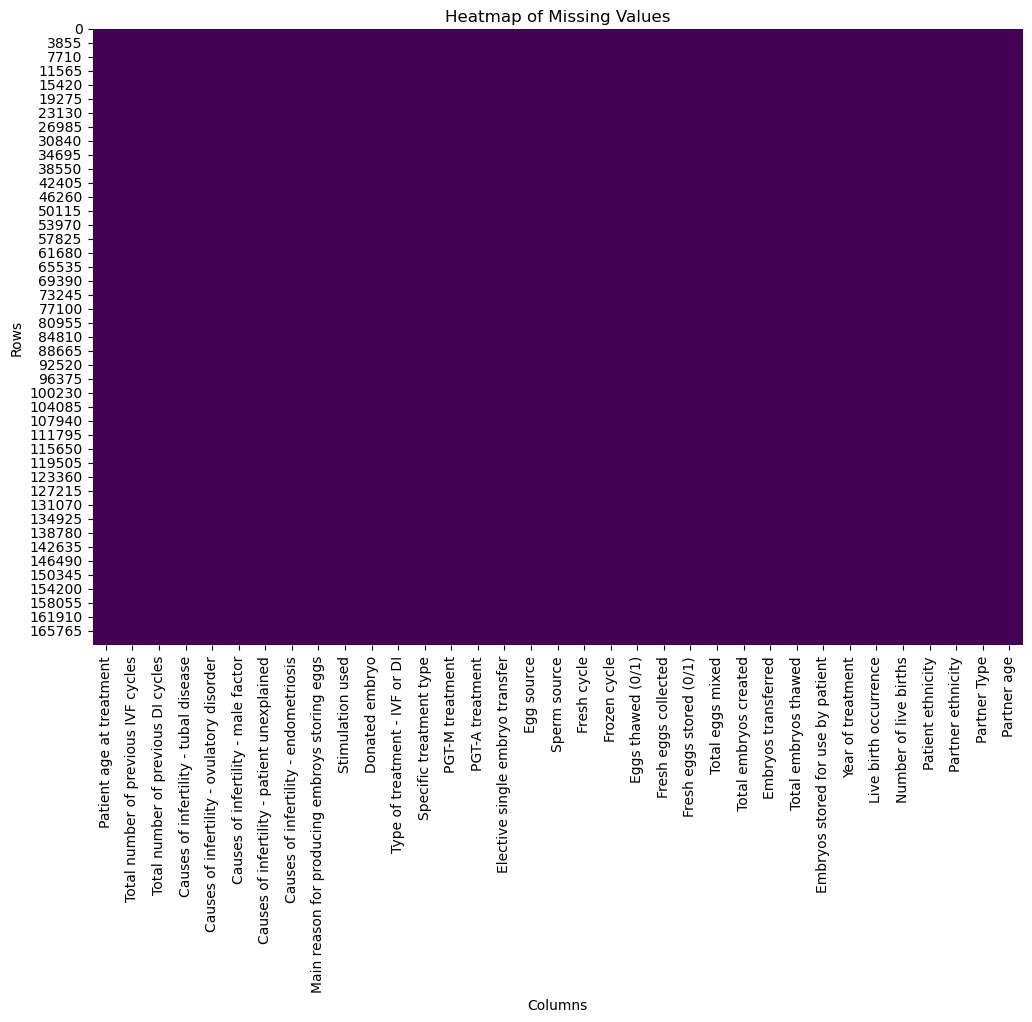

In [42]:
# 결측치 히트맵 그리기
plt.figure(figsize=(12, 8))
sns.heatmap(df_filled.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

## 데이터 저장

In [44]:
df_filled.to_excel('processed_data.xlsx', index=False, engine='openpyxl')